# EDA — Bộ dữ liệu CICIDS2017

## Mục tiêu
Hiểu đầy đủ cấu trúc và chất lượng của bộ dữ liệu CICIDS2017 trước khi triển khai pipeline tiền xử lý cho NIDS dựa trên VAE.

## Phạm vi
- Khám phá tất cả các tệp CSV trong `data/raw/`
- Phân tích cấu trúc và chất lượng bộ dữ liệu
- Xác định các yêu cầu tiền xử lý
- Ghi lại chiến lược tiền xử lý được khuyến nghị

> **Lưu ý:** Notebook này KHÔNG triển khai pipeline tiền xử lý, không fit scaler, không tạo các phân chia dữ liệu hay huấn luyện mô hình.


In [3]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Kết nối Google Drive
from google.colab import drive

drive.mount("/content/drive")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

# ── Đường dẫn ──────────────────────────────────────────────────────────────────
DATA_DIR = Path(r"/content/drive/MyDrive/CICIDS2017")
assert os.path.exists(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"

RANDOM_STATE = 42

print(f"Python  : {sys.version}")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"DATA_DIR: {DATA_DIR.resolve()}")


Mounted at /content/drive
Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas  : 2.2.2
numpy   : 2.0.2
DATA_DIR: /content/drive/MyDrive/CICIDS2017


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 1 — Liệt kê các tệp CSV và ghi lại kích thước
# ─────────────────────────────────────────────────────────────────────────────

csv_files = sorted(DATA_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV file(s):\n")

shape_records = []
for f in csv_files:
    df_tmp = pd.read_csv(f, low_memory=False)
    shape_records.append({"file": f.name, "rows": df_tmp.shape[0], "cols": df_tmp.shape[1]})
    print(f"  {f.name:<60}  rows={df_tmp.shape[0]:>8,}  cols={df_tmp.shape[1]}")
    del df_tmp

shape_df = pd.DataFrame(shape_records)
print(f"\nTotal rows across all files: {shape_df['rows'].sum():,}")
print(f"Column count consistent : {shape_df['cols'].nunique() == 1}")


Found 8 CSV file(s):

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv              rows= 225,745  cols=79
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv          rows= 286,467  cols=79
  Friday-WorkingHours-Morning.pcap_ISCX.csv                     rows= 191,033  cols=79
  Monday-WorkingHours.pcap_ISCX.csv                             rows= 529,918  cols=79
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv   rows= 288,602  cols=79
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv        rows= 170,366  cols=79
  Tuesday-WorkingHours.pcap_ISCX.csv                            rows= 445,909  cols=79
  Wednesday-workingHours.pcap_ISCX.csv                          rows= 692,703  cols=79

Total rows across all files: 2,830,743
Column count consistent : True


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 2 — Xác minh tính nhất quán của schema trên tất cả các tệp
# ─────────────────────────────────────────────────────────────────────────────

column_sets = {}
for f in csv_files:
    df_tmp = pd.read_csv(f, nrows=0, low_memory=False)
    # Loại bỏ khoảng trắng đầu/cuối khỏi tên cột
    cols = [c.strip() for c in df_tmp.columns.tolist()]
    column_sets[f.name] = cols
    del df_tmp

reference_file = list(column_sets.keys())[0]
reference_cols = column_sets[reference_file]
print(f"Reference file : {reference_file}")
print(f"Column count   : {len(reference_cols)}")

all_match = True
for fname, cols in column_sets.items():
    if cols != reference_cols:
        print(f"  MISMATCH: {fname}")
        diff_a = set(reference_cols) - set(cols)
        diff_b = set(cols) - set(reference_cols)
        if diff_a:
            print(f"    Missing in {fname}: {diff_a}")
        if diff_b:
            print(f"    Extra in   {fname}: {diff_b}")
        all_match = False

if all_match:
    print("\n✓ All files share the same schema.")
else:
    print("\n✗ Schema mismatch detected — must be resolved before merging.")


Reference file : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Column count   : 79

✓ All files share the same schema.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 3 — Tải toàn bộ dữ liệu, kiểm tra tên cột và kiểu dữ liệu
# ─────────────────────────────────────────────────────────────────────────────

dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f, low_memory=False)
    # Loại bỏ khoảng trắng khỏi tên cột (đặc điểm phổ biến của CICIDS2017)
    df_tmp.columns = [c.strip() for c in df_tmp.columns]
    df_tmp["_source_file"] = f.name
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
del dfs, df_tmp

# Xác định cột nhãn
LABEL_COL = "Label"
assert LABEL_COL in df.columns, f"Label column '{LABEL_COL}' not found. Columns: {df.columns.tolist()}"

print(f"Combined dataset shape: {df.shape}")
print(f"\nData types:\n")
print(df.dtypes.value_counts().to_string())
print(f"\nObject-typed columns:")
obj_cols = df.select_dtypes(include="object").columns.tolist()
print(obj_cols)


Combined dataset shape: (2830743, 80)

Data types:

int64      54
float64    24
object      2

Object-typed columns:
['Label', '_source_file']


=== Global label distribution ===
                              count   pct_%  is_benign
Label                                                 
BENIGN                      2273097 80.3000       True
DoS Hulk                     231073  8.1630      False
PortScan                     158930  5.6140      False
DDoS                         128027  4.5230      False
DoS GoldenEye                 10293  0.3640      False
FTP-Patator                    7938  0.2800      False
SSH-Patator                    5897  0.2080      False
DoS slowloris                  5796  0.2050      False
DoS Slowhttptest               5499  0.1940      False
Bot                            1966  0.0690      False
Web Attack � Brute Force       1507  0.0530      False
Web Attack � XSS                652  0.0230      False
Infiltration                     36  0.0010      False
Web Attack � Sql Injection       21  0.0010      False
Heartbleed                       11  0.0000      False

BENIGN flows :  2,273,097
Atta

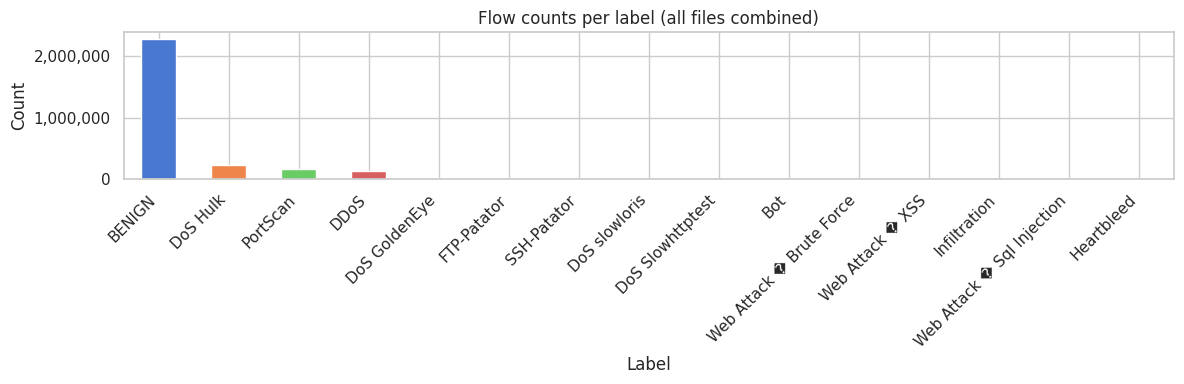

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 4 — Phân tích phân phối nhãn
# ─────────────────────────────────────────────────────────────────────────────

label_counts = df[LABEL_COL].value_counts()
label_pct    = df[LABEL_COL].value_counts(normalize=True) * 100

label_summary = pd.DataFrame({
    "count"  : label_counts,
    "pct_%"  : label_pct.round(3),
    "is_benign": label_counts.index == "BENIGN",
})
print("=== Global label distribution ===")
print(label_summary.to_string())

print(f"\nBENIGN flows : {label_counts.get('BENIGN', 0):>10,}")
print(f"Attack flows  : {label_counts.drop('BENIGN', errors='ignore').sum():>10,}")
print(f"Unique labels : {label_counts.shape[0]}")

# Phân tích nhãn theo từng tệp
print("\n=== Per-file label distribution ===")
per_file = (
    df.groupby("_source_file")[LABEL_COL]
    .value_counts()
    .rename("count")
    .reset_index()
    .sort_values(["_source_file", "count"], ascending=[True, False])
)
print(per_file.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
label_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(label_counts)))
ax.set_title("Flow counts per label (all files combined)")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 5 — Phát hiện giá trị thiếu
# ─────────────────────────────────────────────────────────────────────────────

# Loại trừ cột metadata được thêm bởi notebook này
feature_cols = [c for c in df.columns if c not in (LABEL_COL, "_source_file")]

null_counts = df[feature_cols].isnull().sum()
null_pct    = null_counts / len(df) * 100

missing_df = pd.DataFrame({
    "null_count": null_counts,
    "null_pct_%": null_pct.round(4),
}).query("null_count > 0").sort_values("null_count", ascending=False)

print(f"Total feature columns : {len(feature_cols)}")
print(f"Columns WITH nulls    : {len(missing_df)}\n")

if missing_df.empty:
    print("✓ No missing values found in any feature column.")
else:
    print(missing_df.to_string())

print(f"\nTotal missing cells   : {null_counts.sum():,}")


Total feature columns : 78
Columns WITH nulls    : 1

              null_count  null_pct_%
Flow Bytes/s        1358      0.0480

Total missing cells   : 1,358


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 6 — Phát hiện giá trị vô cực
# ─────────────────────────────────────────────────────────────────────────────

numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

inf_counts = (
    df[numeric_cols]
    .apply(lambda s: np.isinf(s).sum())
    .rename("inf_count")
)
inf_df = inf_counts[inf_counts > 0].sort_values(ascending=False)

print(f"Numeric feature columns : {len(numeric_cols)}")
print(f"Columns WITH infinities : {len(inf_df)}\n")

if inf_df.empty:
    print("✓ No infinite values found.")
else:
    inf_pct = (inf_df / len(df) * 100).rename("inf_pct_%").round(4)
    print(pd.concat([inf_df, inf_pct], axis=1).to_string())

print(f"\nTotal infinite cells : {int(inf_counts.sum()):,}")


Numeric feature columns : 78
Columns WITH infinities : 2

                inf_count  inf_pct_%
Flow Packets/s       2867     0.1013
Flow Bytes/s         1509     0.0533

Total infinite cells : 4,376


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 7 — Phát hiện hàng trùng lặp
# ─────────────────────────────────────────────────────────────────────────────

n_duplicates = df.drop(columns=["_source_file"]).duplicated().sum()
dup_pct = n_duplicates / len(df) * 100

print(f"Total rows           : {len(df):,}")
print(f"Duplicate rows       : {n_duplicates:,}  ({dup_pct:.3f}%)")

if n_duplicates > 0:
    print("\nSample duplicated rows (first 5):")
    dup_mask = df.drop(columns=["_source_file"]).duplicated(keep=False)
    print(df[dup_mask].head())
else:
    print("✓ No exact duplicate rows found.")


Total rows           : 2,830,743
Duplicate rows       : 308,381  (10.894%)

Sample duplicated rows (first 5):
     Destination Port  Flow Duration  Total Fwd Packets  \
76                 21             50                  1   
109                22            187                  1   
111                22            111                  1   
384               443            161                  2   
386               465             49                  2   

     Total Backward Packets  Total Length of Fwd Packets  \
76                        2                            0   
109                       1                            0   
111                       1                            0   
384                       0                            0   
386                       0                           37   

     Total Length of Bwd Packets  Fwd Packet Length Max  \
76                             0                      0   
109                            0                      0 

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 8 — Các cột hằng số và gần hằng số (phương sai thấp)
# ─────────────────────────────────────────────────────────────────────────────

# Hằng số: chỉ có một giá trị duy nhất
constant_cols = [c for c in numeric_cols if df[c].dropna().nunique() <= 1]
print(f"Constant columns ({len(constant_cols)}):")
for c in constant_cols:
    print(f"  {c}  value={df[c].dropna().unique()}")

# Gần hằng số: một giá trị chiếm >= 99% các hàng không null
print(f"\nNear-constant columns (top value >= 99% of non-null rows):")
near_constant = []
for c in numeric_cols:
    if c in constant_cols:
        continue
    s = df[c].dropna()
    if len(s) == 0:
        continue
    top_frac = s.value_counts(normalize=True).iloc[0]
    if top_frac >= 0.99:
        near_constant.append((c, round(top_frac * 100, 2), s.value_counts().index[0]))

if near_constant:
    near_const_df = pd.DataFrame(near_constant, columns=["column", "top_pct_%", "top_value"])
    print(near_const_df.to_string(index=False))
else:
    print("  None found.")


Constant columns (8):
  Bwd PSH Flags  value=[0]
  Bwd URG Flags  value=[0]
  Fwd Avg Bytes/Bulk  value=[0]
  Fwd Avg Packets/Bulk  value=[0]
  Fwd Avg Bulk Rate  value=[0]
  Bwd Avg Bytes/Bulk  value=[0]
  Bwd Avg Packets/Bulk  value=[0]
  Bwd Avg Bulk Rate  value=[0]

Near-constant columns (top value >= 99% of non-null rows):
        column  top_pct_%  top_value
 Fwd URG Flags    99.9900          0
RST Flag Count    99.9800          0
CWE Flag Count    99.9900          0
ECE Flag Count    99.9800          0


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 9 — Phân tích mức sử dụng bộ nhớ
# ─────────────────────────────────────────────────────────────────────────────

mem_bytes   = df.memory_usage(deep=True).sum()
mem_mb      = mem_bytes / 1024 ** 2
print(f"Total in-memory size : {mem_mb:.1f} MB  ({mem_bytes:,} bytes)")

col_mem = (
    df.memory_usage(deep=True)
    .drop("Index")
    .sort_values(ascending=False)
    .head(15)
    .apply(lambda x: f"{x / 1024**2:.2f} MB")
)
print(f"\nTop 15 columns by memory usage:")
print(col_mem.to_string())


Total in-memory size : 2078.1 MB  (2,179,085,283 bytes)

Top 15 columns by memory usage:
_source_file                   244.22 MB
Label                          149.36 MB
Destination Port                21.60 MB
Flow Duration                   21.60 MB
Total Length of Fwd Packets     21.60 MB
Total Length of Bwd Packets     21.60 MB
Total Fwd Packets               21.60 MB
Total Backward Packets          21.60 MB
Fwd Packet Length Mean          21.60 MB
Fwd Packet Length Std           21.60 MB
Bwd Packet Length Max           21.60 MB
Bwd Packet Length Min           21.60 MB
Bwd Packet Length Mean          21.60 MB
Bwd Packet Length Std           21.60 MB
Fwd Packet Length Max           21.60 MB


Descriptive statistics (first 20 numeric columns):
                                   count          mean           std             min      5%      25%        50%          75%            95%             max  skewness    kurtosis  n_inf
Destination Port            2830743.0000     8071.4825    18283.6322          0.0000 53.0000  53.0000    80.0000     443.0000     55228.0000      65535.0000    2.0721      2.5182      0
Flow Duration               2830743.0000 14785663.9295 33653744.0858        -13.0000  4.0000 155.0000 31316.0000 3204828.5000 101114583.8000  119999998.0000    2.1554      3.0203      0
Total Fwd Packets           2830743.0000        9.3612      749.6728          1.0000  1.0000   2.0000     2.0000       5.0000        19.0000     219759.0000  244.3806  61754.4313      0
Total Backward Packets      2830743.0000       10.3938      997.3883          0.0000  0.0000   1.0000     2.0000       4.0000        17.0000     291922.0000  244.6795  62017.9755      0
Total Length of Fwd

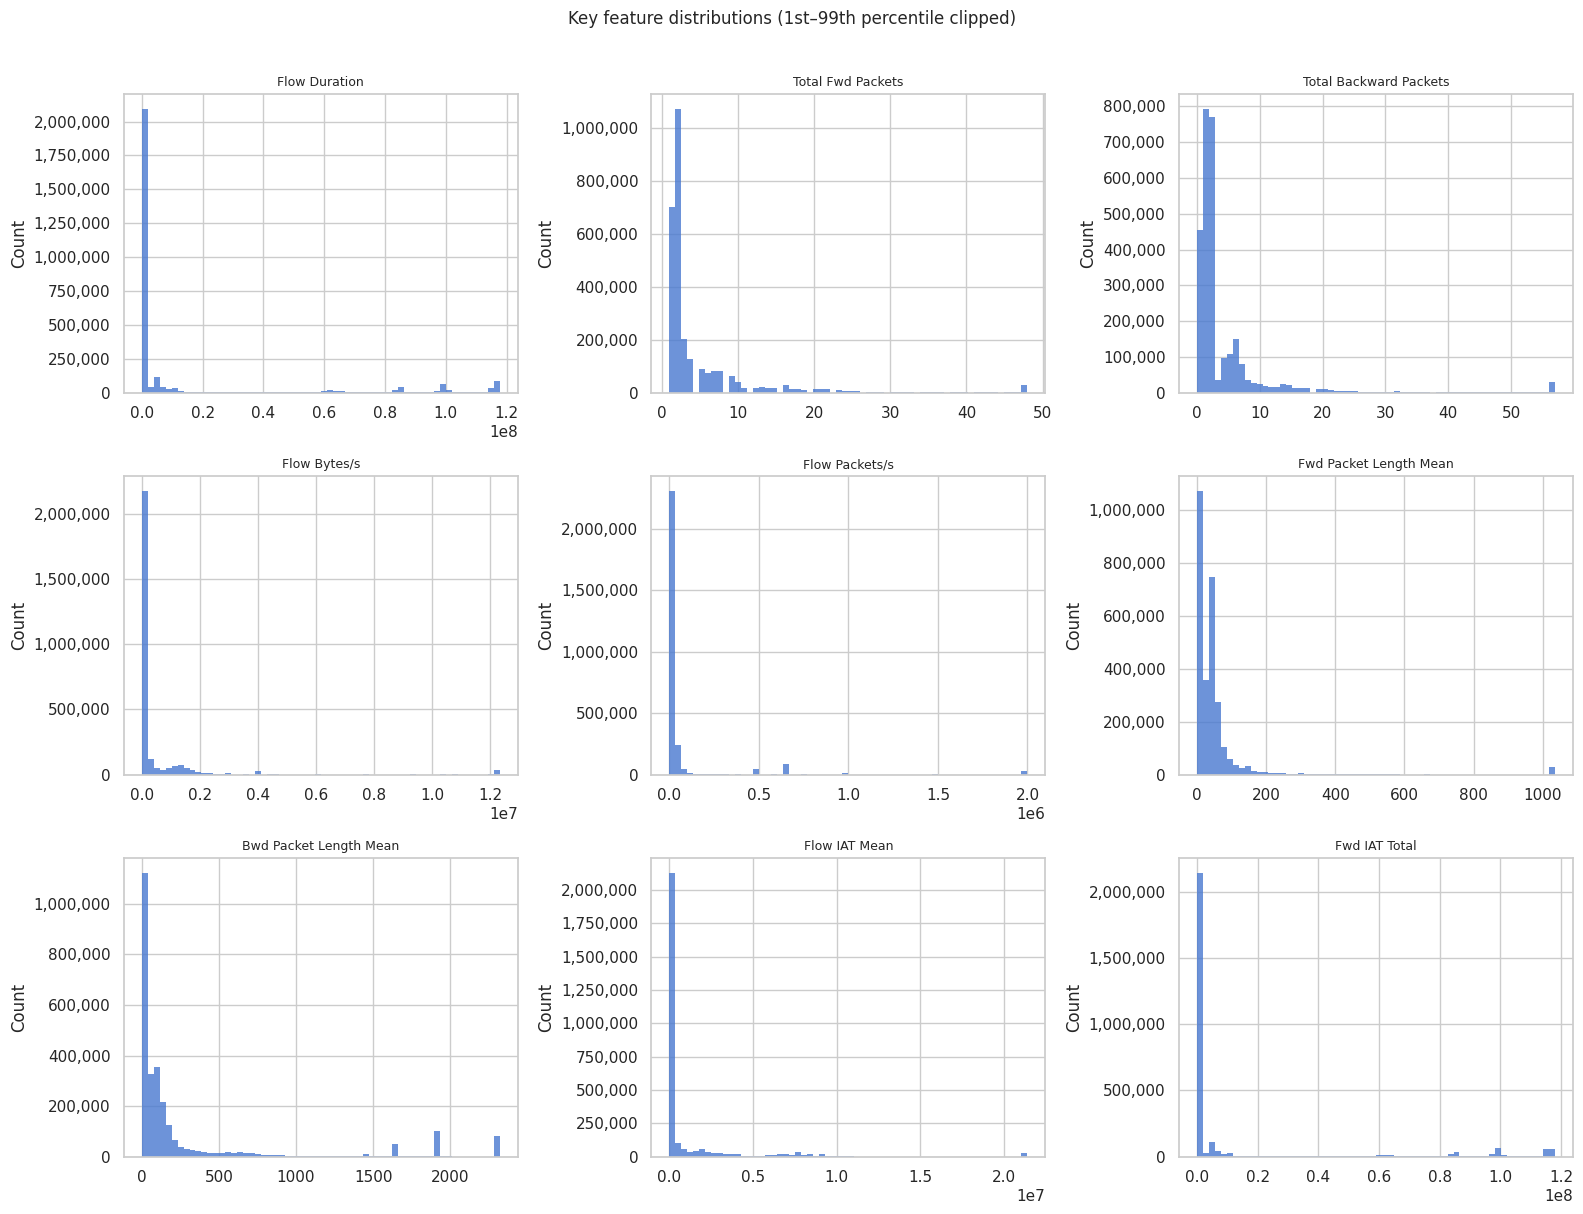

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 10 — Thống kê mô tả và phân phối đặc trưng
# ─────────────────────────────────────────────────────────────────────────────

# Thay thế inf bằng NaN chỉ cho phân tích này (không sửa đổi df)
df_stats = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

desc = df_stats.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["skewness"] = df_stats.skew()
desc["kurtosis"] = df_stats.kurtosis()
desc["n_inf"]    = (np.isinf(df[numeric_cols]).sum()).values

print("Descriptive statistics (first 20 numeric columns):")
print(desc.head(20).to_string())

# ── Biểu đồ phân phối đặc trưng chính ────────────────────────────────────────
KEY_FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Flow IAT Mean",
    "Fwd IAT Total",
]

# Chỉ giữ những cột thực sự tồn tại trong bộ dữ liệu
KEY_FEATURES = [c for c in KEY_FEATURES if c in df_stats.columns]

n_cols = 3
n_rows = (len(KEY_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    data = df_stats[col].dropna()
    # Cắt các ngoại lệ cực đoan để dễ đọc (chỉ để vẽ đồ thị)
    q_low, q_high = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data.clip(q_low, q_high)
    axes[i].hist(data_clipped, bins=60, color=sns.color_palette("muted")[0], edgecolor="none", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Count")
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Ẩn các trục không dùng
for j in range(len(KEY_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Key feature distributions (1st–99th percentile clipped)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


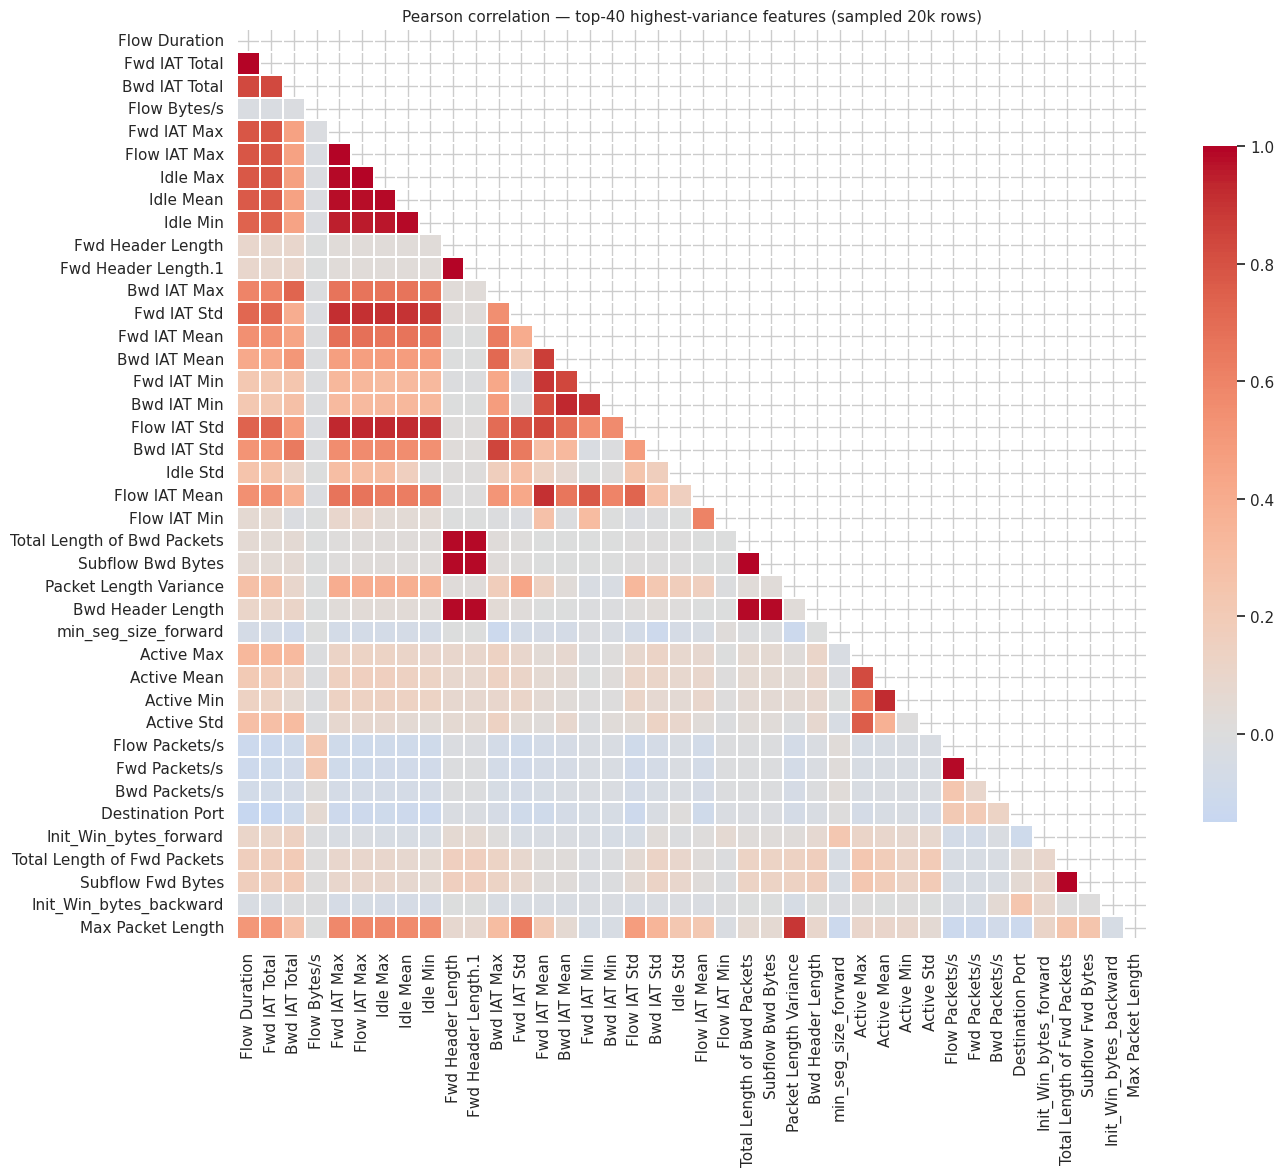

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 11 — Bản đồ nhiệt tương quan (đặc trưng số, lấy mẫu)
# ─────────────────────────────────────────────────────────────────────────────
import random
random.seed(RANDOM_STATE)

# Dùng mẫu phân tầng để tối ưu hiệu năng
sample_n  = min(20_000, len(df))
df_sample = df_stats.sample(n=sample_n, random_state=RANDOM_STATE)

# Tính tương quan trên dữ liệu mẫu
corr = df_sample.corr()

# Vẽ 40 cột có phương sai cao nhất để dễ đọc
top_var_cols = df_stats.var().nlargest(40).index
corr_sub = corr.loc[top_var_cols, top_var_cols]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(
    corr_sub, mask=mask, cmap="coolwarm", center=0,
    linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7},
    annot=False, square=True,
)
ax.set_title("Pearson correlation — top-40 highest-variance features (sampled 20k rows)", fontsize=11)
plt.tight_layout()
plt.show()


=== Monday-WorkingHours.pcap_ISCX.csv ===
Shape  : (529918, 80)

Label distribution:
Label
BENIGN    529918

✓ All Monday flows are BENIGN — confirmed as primary normal-traffic training source.

Monday inf  values : 810
Monday null values : 64


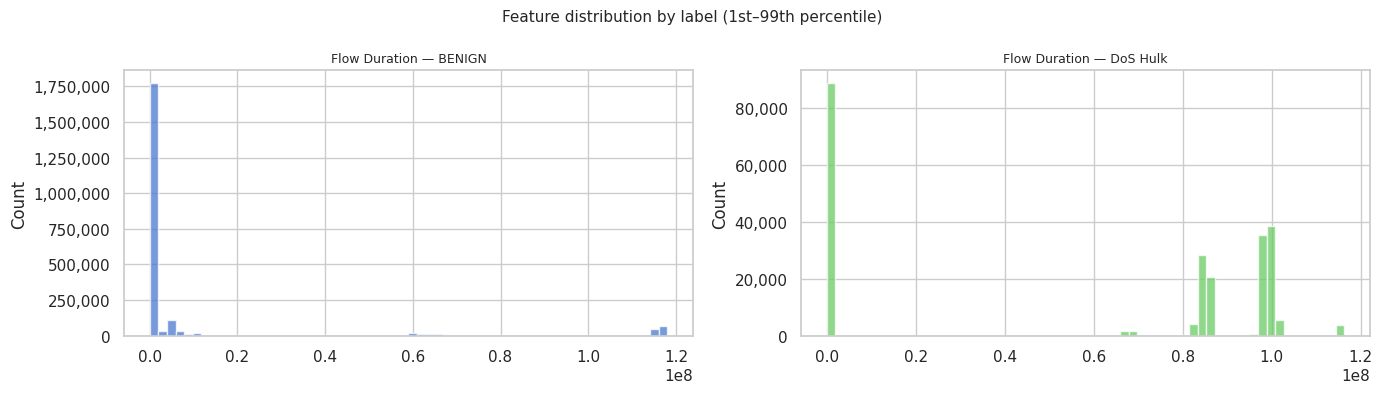

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 12 — Monday-WorkingHours: nguồn dữ liệu BENIGN chính để huấn luyện
# ─────────────────────────────────────────────────────────────────────────────

monday_file = "Monday-WorkingHours.pcap_ISCX.csv"
df_monday   = df[df["_source_file"] == monday_file].copy()

print(f"=== {monday_file} ===")
print(f"Shape  : {df_monday.shape}")
print(f"\nLabel distribution:")
print(df_monday[LABEL_COL].value_counts().to_string())

# Xác nhận toàn bộ lưu lượng thứ Hai là BENIGN
assert (df_monday[LABEL_COL] == "BENIGN").all(), \
    "Monday file contains non-BENIGN labels — investigate before using as sole normal-traffic source."
print("\n✓ All Monday flows are BENIGN — confirmed as primary normal-traffic training source.")

# Kiểm tra Inf / NaN trong dữ liệu thứ Hai
mon_inf  = np.isinf(df_monday[numeric_cols]).sum().sum()
mon_null = df_monday[numeric_cols].isnull().sum().sum()
print(f"\nMonday inf  values : {mon_inf:,}")
print(f"Monday null values : {mon_null:,}")

# Phân phối một đặc trưng luồng chính theo nhãn trên toàn bộ dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

col_show = "Flow Duration" if "Flow Duration" in df_stats.columns else numeric_cols[0]

for ax, label_val in zip(axes, ["BENIGN", df[LABEL_COL].value_counts().index[1] if len(label_counts) > 1 else "BENIGN"]):
    sub = df_stats[df[LABEL_COL] == label_val][col_show].dropna()
    q1, q99 = sub.quantile(0.01), sub.quantile(0.99)
    ax.hist(sub.clip(q1, q99), bins=60, alpha=0.75, color=sns.color_palette("muted")[0 if label_val == "BENIGN" else 2])
    ax.set_title(f"{col_show} — {label_val}", fontsize=9)
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Feature distribution by label (1st–99th percentile)", fontsize=11)
plt.tight_layout()
plt.show()


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 13 — Xác định các cột cần loại bỏ (không phải đặc trưng / không phải số)
# ─────────────────────────────────────────────────────────────────────────────

NON_FEATURE_COLS = [LABEL_COL, "_source_file"]

# Các cột kiểu object còn lại ngoài Label
extra_obj_cols = [c for c in obj_cols if c not in NON_FEATURE_COLS]
print(f"Non-feature columns that will be excluded from model input:")
for c in NON_FEATURE_COLS:
    print(f"  {c}")
if extra_obj_cols:
    print(f"\nAdditional object-typed columns (review needed):")
    for c in extra_obj_cols:
        print(f"  {c}  |  sample values: {df[c].dropna().unique()[:5]}")
else:
    print("\nNo additional object columns — only the label column is non-numeric.")

# Các cột đặc trưng ứng viên cuối cùng
candidate_features = [c for c in numeric_cols if c not in constant_cols]
print(f"\nCandidate numeric feature columns after removing constants : {len(candidate_features)}")

# Các cột được đánh dấu để xem xét loại bỏ
cols_to_investigate = {
    "constant"     : constant_cols,
    "near_constant": [r[0] for r in near_constant],
    "inf_affected" : inf_df.index.tolist() if not inf_df.empty else [],
}
print("\nColumns to investigate / handle:")
for category, cols in cols_to_investigate.items():
    print(f"  {category:<20}: {len(cols)} column(s) → {cols[:10]}")


Non-feature columns that will be excluded from model input:
  Label
  _source_file

No additional object columns — only the label column is non-numeric.

Candidate numeric feature columns after removing constants : 70

Columns to investigate / handle:
  constant            : 8 column(s) → ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
  near_constant       : 4 column(s) → ['Fwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count']
  inf_affected        : 2 column(s) → ['Flow Packets/s', 'Flow Bytes/s']


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Section 14 — Các kiểm định và cổng chất lượng
# ─────────────────────────────────────────────────────────────────────────────

print("Running quality assertions...\n")

# 1. Tất cả tệp đã được tải
assert len(csv_files) == 8, f"Expected 8 CSV files, found {len(csv_files)}"
print(f"✓ Found {len(csv_files)} CSV files")

# 2. Cột nhãn có mặt
assert LABEL_COL in df.columns, "Label column missing"
print(f"✓ Label column '{LABEL_COL}' present")

# 3. Tệp thứ Hai toàn bộ là BENIGN
assert (df[df["_source_file"] == "Monday-WorkingHours.pcap_ISCX.csv"][LABEL_COL] == "BENIGN").all()
print("✓ Monday file contains only BENIGN flows")

# 4. Luồng BENIGN tồn tại trong nhiều tệp
benign_sources = df[df[LABEL_COL] == "BENIGN"]["_source_file"].nunique()
assert benign_sources > 1, "BENIGN flows should appear in multiple files"
print(f"✓ BENIGN flows present in {benign_sources} file(s)")

# 5. Số lượng cột nhất quán
assert shape_df["cols"].nunique() == 1, "Column count differs across files"
print(f"✓ Consistent column count ({shape_df['cols'].iloc[0]}) across all files")

# 6. Không có cột toàn null
all_null_cols = [c for c in feature_cols if df[c].isnull().all()]
assert len(all_null_cols) == 0, f"All-null columns: {all_null_cols}"
print(f"✓ No all-null feature columns")

print("\n=== All quality assertions passed ===")


Running quality assertions...

✓ Found 8 CSV files
✓ Label column 'Label' present
✓ Monday file contains only BENIGN flows
✓ BENIGN flows present in 8 file(s)
✓ Consistent column count (79) across all files
✓ No all-null feature columns

=== All quality assertions passed ===


# Section 15 — Chiến lược tiền xử lý được khuyến nghị

Dựa trên kết quả EDA ở trên, các bước tiền xử lý sau đây là cần thiết trước khi huấn luyện VAE.

---

## Các vấn đề chất lượng dữ liệu được phát hiện

| Vấn đề | Tác động | Cách xử lý |
|---|---|---|
| Giá trị vô cực trong `Flow Bytes/s`, `Flow Packets/s` | Làm hỏng scaler | Thay `±Inf` → `NaN`, sau đó impute |
| Giá trị NaN (thường từ các luồng có thời gian bằng 0) | Làm hỏng scaler | Impute bằng median (tính trên tập huấn luyện) |
| Hàng trùng lặp | Nhiễu trong huấn luyện | Loại bỏ các hàng trùng chính xác sau khi tách nhãn |
| Cột hằng số / gần hằng số | Phương sai bằng 0, vô dụng với mô hình | Loại bỏ trước khi scaling |
| Cột không phải số (`Label`, metadata) | Không thể đưa vào VAE | Loại trừ khỏi ma trận đặc trưng |

---

## Các bước tiền xử lý được khuyến nghị cho `clean_data.py`

1. **Tải CSV thô** — nối tất cả các tệp, loại bỏ khoảng trắng khỏi tên cột.
2. **Tách nhãn** — trích xuất cột `Label` trước khi biến đổi đặc trưng.
3. **Loại bỏ cột không phải đặc trưng** — xóa `Label`, các cột định danh hoặc timestamp.
4. **Chuyển đổi sang kiểu số** — `pd.to_numeric(..., errors='coerce')` trên tất cả các cột đặc trưng.
5. **Thay thế giá trị vô cực** — `df.replace([np.inf, -np.inf], np.nan)`.
6. **Loại bỏ cột hằng số** — các cột có phương sai bằng 0 trên toàn bộ dữ liệu.
7. **Loại bỏ hàng trùng lặp** — sau khi tách nhãn, trên cặp đặc trưng + nhãn.
8. **Ghi lại danh sách đặc trưng cuối cùng** — xuất ra `artifacts/feature_schema/feature_columns.json`.
9. **Lưu dữ liệu đã làm sạch** — ghi vào `data/processed/` giữ nguyên nhãn gốc để đánh giá.

> Việc fit scaler và chia tập train/val/test được thực hiện ở **bước tiếp theo** (`scripts/train.py`), KHÔNG phải ở đây.

---

## Vai trò của tệp thứ Hai

`Monday-WorkingHours.pcap_ISCX.csv` là tệp **duy nhất** 100% là BENIGN.  
Nó được chỉ định là nguồn chính cung cấp mẫu lưu lượng bình thường để huấn luyện VAE.  
Các hàng BENIGN từ các tệp tấn công có thể được dùng để bổ sung vào tập lưu lượng bình thường.

---

## Quy tắc impute NaN

- Chiến lược: **impute bằng median**, tính trên tập huấn luyện.
- Các giá trị median phải được lưu cùng với artifact scaler để có thể áp dụng cùng phương pháp impute khi inference mà không cần fit lại.
- **Không** dùng impute bằng mean — các đặc trưng luồng có phân phối lệch phải mạnh.

---

## Hợp đồng thứ tự đặc trưng

Thứ tự các cột đặc trưng trong `artifacts/feature_schema/feature_columns.json` là nguồn sự thật duy nhất.  
Huấn luyện, đánh giá và inference đều phải tải và áp dụng schema này.
